# ARTI406 - Assignment 2
## Apple Stock Dataset Data Preprocessing

This notebook follows the Assignment 2 workflow using the Apple stock price dataset.


In [6]:
# Import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## 1. Load Dataset


In [7]:
df = pd.read_csv("AAPL_Stock_Price_Dataset.csv")
print("Shape:", df.shape)
df.head()


Shape: (11354, 9)


,Date,Open,High,Low,Close,Volume,Daily_Return,Price_Range,Price_Change
0,1980-12-15,0.093684,0.093684,0.093256,0.093256,175884800,NaN,0.000428,-0.000428
1,1980-12-16,0.086839,0.086839,0.086412,0.086412,105728000,-7.339797,0.000428,-0.000428
2,1980-12-17,0.088550,0.088978,0.088550,0.088550,86441600,2.475132,0.000428,0.000000
3,1980-12-18,0.091118,0.091545,0.091118,0.091118,73449600,2.899260,0.000428,0.000000
4,1980-12-19,0.096678,0.097106,0.096678,0.096678,48630400,6.102835,0.000428,0.000000


## 2. Data Quality Assessment


In [8]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 11354 entries, 0 to 11353
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          11354 non-null  str    
 1   Open          11354 non-null  float64
 2   High          11354 non-null  float64
 3   Low           11354 non-null  float64
 4   Close         11354 non-null  float64
 5   Volume        11354 non-null  int64  
 6   Daily_Return  11353 non-null  float64
 7   Price_Range   11354 non-null  float64
 8   Price_Change  11354 non-null  float64
dtypes: float64(7), int64(1), str(1)
memory usage: 798.5 KB


The `Date` column is loaded as text, while the rest of the stock indicators are numeric.
We convert `Date` to a proper datetime type before continuing.


### 2.1 Convert Incorrect Data Types


In [9]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df.dtypes


Date            datetime64[us]
Open                   float64
High                   float64
Low                    float64
Close                  float64
Volume                   int64
Daily_Return           float64
Price_Range            float64
Price_Change           float64
dtype: object

`Date` is now stored as `datetime64[ns]`, which makes time-based analysis and resampling possible.


### 2.2 Basic Data Checks


In [10]:
quality_report = pd.DataFrame(
    {
        "missing_values": df.isna().sum(),
        "duplicates": [df.duplicated().sum()] * len(df.columns),
        "unique_values": df.nunique(),
    },
    index=df.columns,
)
quality_report


,missing_values,duplicates,unique_values
Date,0,0,11354
Open,0,0,10735
High,0,0,10565
Low,0,0,10378
Close,0,0,8340
Volume,0,0,10790
Daily_Return,1,0,10697
Price_Range,0,0,10856
Price_Change,0,0,10319


## 3. Handling Missing Values


In [11]:
df.isna().sum()


Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Daily_Return    1
Price_Range     0
Price_Change    0
dtype: int64

The original dataset has a missing value in `Daily_Return`, which is expected for the first trading day.
To demonstrate preprocessing strategies clearly, artificial missing values are added to `Close` and `Volume`.


### 3.1 Demonstration: Introduce Artificial Missing Values


In [12]:
df_missing = df.copy()
close_idx = df_missing.sample(15, random_state=42).index
volume_idx = df_missing.sample(15, random_state=7).index

df_missing.loc[close_idx, "Close"] = np.nan
df_missing.loc[volume_idx, "Volume"] = np.nan

df_missing[["Date", "Close", "Volume"]].head(10)


,Date,Close,Volume
0,1980-12-15,0.093256,175884800.0
1,1980-12-16,0.086412,105728000.0
2,1980-12-17,0.088550,86441600.0
3,1980-12-18,0.091118,73449600.0
4,1980-12-19,0.096678,48630400.0
5,1980-12-22,0.101384,37363200.0
6,1980-12-23,0.105662,46950400.0
7,1980-12-24,0.111223,48003200.0
8,1980-12-26,0.121490,55574400.0
9,1980-12-29,0.123201,93161600.0


In [13]:
print("Original shape:", df.shape)
print("Missing-value demo shape:", df_missing.shape)
df_missing.isna().sum()


Original shape: (11354, 9)
Missing-value demo shape: (11354, 9)


Date             0
Open             0
High             0
Low              0
Close           15
Volume          15
Daily_Return     1
Price_Range      0
Price_Change     0
dtype: int64

### Strategy 1: Remove Records


In [14]:
df_removed = df_missing.dropna()
print("Shape after dropping rows with missing values:", df_removed.shape)
df_removed.isna().sum()


Shape after dropping rows with missing values: (11324, 9)


Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Daily_Return    0
Price_Range     0
Price_Change    0
dtype: int64

Dropping rows removes all missing values, but it also reduces the number of observations.


### Strategy 2: Mean Imputation


In [15]:
df_imputed_mean = df_missing.copy()
df_imputed_mean["Close"] = df_imputed_mean["Close"].fillna(df_imputed_mean["Close"].mean())
df_imputed_mean["Volume"] = df_imputed_mean["Volume"].fillna(df_imputed_mean["Volume"].mean())
df_imputed_mean["Daily_Return"] = df_imputed_mean["Daily_Return"].fillna(df_imputed_mean["Daily_Return"].mean())

df_imputed_mean.loc[close_idx.union(volume_idx), ["Date", "Close", "Volume", "Daily_Return"]].head(10)


,Date,Close,Volume,Daily_Return
101,1981-05-11,27.978053,1.193920e+07,-2.232072
398,1982-07-14,27.978053,7.112000e+07,1.010043
623,1983-06-02,0.200202,3.098169e+08,0.645125
651,1983-07-13,27.978053,1.290016e+08,-0.539048
1408,1986-07-11,27.978053,2.240000e+08,4.947318
1793,1988-01-19,27.978053,2.744000e+08,0.000000
2168,1989-07-13,27.978053,2.254336e+08,1.562415
2301,1990-01-22,27.978053,1.456112e+08,-2.919863
2341,1990-03-20,0.290781,3.098169e+08,-2.359704
2510,1990-11-16,0.249119,3.098169e+08,-2.104496


Mean imputation preserves the dataset size, but it can smooth away natural variation.


### Strategy 3: Median Imputation


In [16]:
df_imputed_median = df_missing.copy()
df_imputed_median["Close"] = df_imputed_median["Close"].fillna(df_imputed_median["Close"].median())
df_imputed_median["Volume"] = df_imputed_median["Volume"].fillna(df_imputed_median["Volume"].median())
df_imputed_median["Daily_Return"] = df_imputed_median["Daily_Return"].fillna(df_imputed_median["Daily_Return"].median())

df_imputed_median.loc[close_idx.union(volume_idx), ["Date", "Close", "Volume", "Daily_Return"]].head(10)


,Date,Close,Volume,Daily_Return
101,1981-05-11,0.483906,11939200.0,-2.232072
398,1982-07-14,0.483906,71120000.0,1.010043
623,1983-06-02,0.200202,198844800.0,0.645125
651,1983-07-13,0.483906,129001600.0,-0.539048
1408,1986-07-11,0.483906,224000000.0,4.947318
1793,1988-01-19,0.483906,274400000.0,0.000000
2168,1989-07-13,0.483906,225433600.0,1.562415
2301,1990-01-22,0.483906,145611200.0,-2.919863
2341,1990-03-20,0.290781,198844800.0,-2.359704
2510,1990-11-16,0.249119,198844800.0,-2.104496


Median imputation is often more robust than the mean when the data includes extreme values.


## 4. Handling Outliers


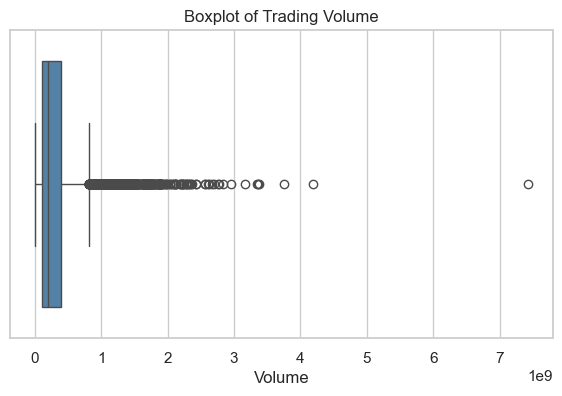

In [17]:
plt.figure(figsize=(7, 4))
sns.boxplot(x=df["Volume"], color="steelblue")
plt.title("Boxplot of Trading Volume")
plt.xlabel("Volume")
plt.show()


Trading volume is strongly right-skewed, so it is a good feature for outlier detection.


### Detect Outliers using IQR


In [18]:
Q1 = df["Volume"].quantile(0.25)
Q3 = df["Volume"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Volume"] < lower) | (df["Volume"] > upper)]
print("Number of outliers:", outliers.shape[0])
outliers[["Date", "Volume", "Close"]].head(10)


Number of outliers: 818


,Date,Volume,Close
702,1983-09-23,2832345600,0.082990
734,1983-11-08,1221516800,0.061173
1330,1986-03-20,904131200,0.096678
1504,1986-11-25,848960000,0.137746
2053,1989-01-27,2127171200,0.261014
2065,1989-02-14,891576000,0.248005
2274,1989-12-12,1025416000,0.252193
2490,1990-10-19,933732800,0.221781
2552,1991-01-18,943241600,0.356391
2611,1991-04-15,1700384000,0.442428


The IQR rule identifies unusually high-volume trading days relative to the typical market activity.


### Remove Outliers


In [19]:
df_no_outliers = df[(df["Volume"] >= lower) & (df["Volume"] <= upper)]
print("Original shape:", df.shape)
print("Without outliers:", df_no_outliers.shape)


Original shape: (11354, 9)
Without outliers: (10536, 9)


Removing outliers reduces the dataset size and can hide important market events, so it should be used carefully.


### Capping Outliers (Percentile Method)


In [20]:
df_capped = df.copy()
lower_cap = df_capped["Volume"].quantile(0.05)
upper_cap = df_capped["Volume"].quantile(0.95)
df_capped["Volume_Capped"] = df_capped["Volume"].clip(lower=lower_cap, upper=upper_cap)

df_capped[["Volume", "Volume_Capped"]].describe().T


,count,mean,std,min,25%,50%,75%,max
Volume,11354.0,3.097171e+08,3.334170e+08,0.0,106254850.0,198822400.0,390145000.0,7.421641e+09
Volume_Capped,11354.0,2.894707e+08,2.490550e+08,45494355.0,106254850.0,198822400.0,390145000.0,9.446696e+08


## 5. Data Transformation - Normalization


In [21]:
features_to_scale = ["Open", "High", "Low", "Close", "Volume"]
df[features_to_scale].head()


,Open,High,Low,Close,Volume
0,0.093684,0.093684,0.093256,0.093256,175884800
1,0.086839,0.086839,0.086412,0.086412,105728000
2,0.088550,0.088978,0.088550,0.088550,86441600
3,0.091118,0.091545,0.091118,0.091118,73449600
4,0.096678,0.097106,0.096678,0.096678,48630400


In [22]:
df_minmax = df.copy()
minmax_scaled = (df[features_to_scale] - df[features_to_scale].min()) / (
    df[features_to_scale].max() - df[features_to_scale].min()
)
df_minmax[[f"{col}_MinMax" for col in features_to_scale]] = minmax_scaled
df_minmax[[f"{col}_MinMax" for col in features_to_scale]].head()


,Open_MinMax,High_MinMax,Low_MinMax,Close_MinMax,Volume_MinMax
0,0.000194,0.000193,0.000196,0.000194,0.023699
1,0.000170,0.000169,0.000172,0.000170,0.014246
2,0.000176,0.000176,0.000180,0.000178,0.011647
3,0.000185,0.000185,0.000189,0.000187,0.009897
4,0.000205,0.000205,0.000208,0.000206,0.006553


Min-Max normalization rescales each selected feature to the range from 0 to 1.


### Z-Score Normalization


In [23]:
df_zscore = df.copy()
zscore_scaled = (df[features_to_scale] - df[features_to_scale].mean()) / df[features_to_scale].std()
df_zscore[[f"{col}_ZScore" for col in features_to_scale]] = zscore_scaled
df_zscore[[f"{col}_ZScore" for col in features_to_scale]].head()


,Open_ZScore,High_ZScore,Low_ZScore,Close_ZScore,Volume_ZScore
0,-0.482136,-0.482205,-0.481947,-0.482062,-0.401396
1,-0.482254,-0.482322,-0.482067,-0.482180,-0.611814
2,-0.482225,-0.482286,-0.482029,-0.482143,-0.669658
3,-0.482180,-0.482242,-0.481984,-0.482099,-0.708624
4,-0.482084,-0.482147,-0.481887,-0.482003,-0.783063


Z-score normalization centers the features around 0 with a standard deviation close to 1.


## Check Correlation Before Applying PCA


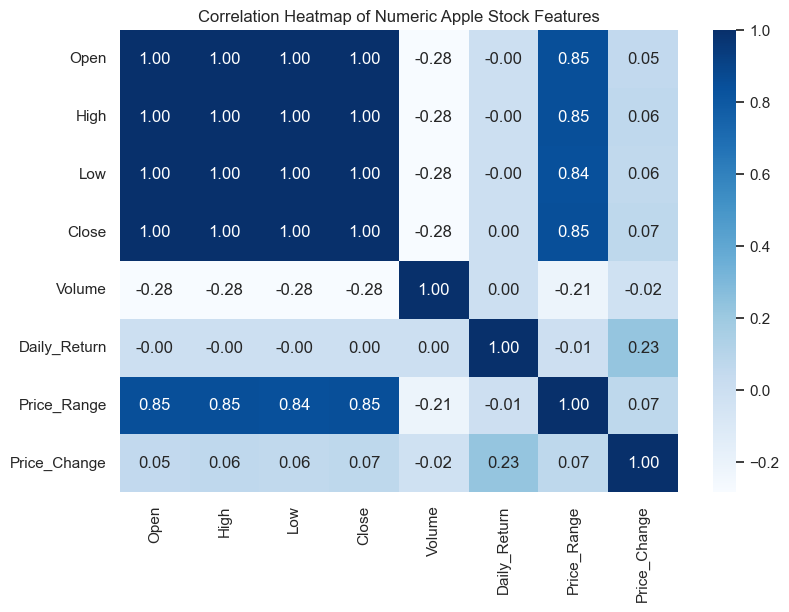

In [24]:
numeric_df = df.select_dtypes(include=[np.number]).dropna()
plt.figure(figsize=(9, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Apple Stock Features")
plt.show()


The price-based columns are highly correlated, which makes dimensionality reduction useful.


## 6. Data Reduction - Principal Component Analysis (PCA)


### Visual Intuition


In [25]:
pca_features = ["Open", "High", "Low", "Close", "Volume", "Price_Range", "Price_Change", "Daily_Return"]
pca_data = df[pca_features].dropna()

pca_scaled = (pca_data - pca_data.mean()) / pca_data.std()
covariance_matrix = np.cov(pca_scaled, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

sorted_idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_idx]
eigenvectors = eigenvectors[:, sorted_idx]

principal_components = pca_scaled.to_numpy() @ eigenvectors[:, :2]
explained_variance_ratio = eigenvalues[:2] / eigenvalues.sum()

pca_df = pd.DataFrame(principal_components, columns=["PC1", "PC2"])
print("Explained variance ratio:", explained_variance_ratio)
pca_df.head()


Explained variance ratio: [0.60751354 0.15298521]


,PC1,PC2
0,0.947541,-1.910837
1,0.933746,0.613758
2,0.927427,0.722554
3,0.914174,1.546036
4,0.909394,1.227863


The explained variance ratio shows how much of the original information is retained by the first two principal components.


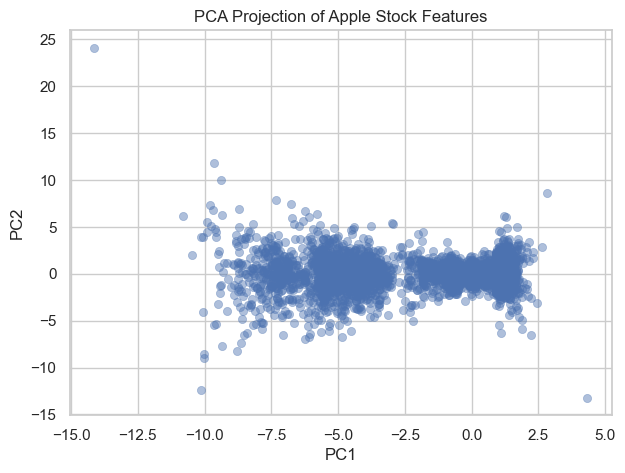

In [26]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", alpha=0.45, s=35, edgecolor=None)
plt.title("PCA Projection of Apple Stock Features")
plt.show()


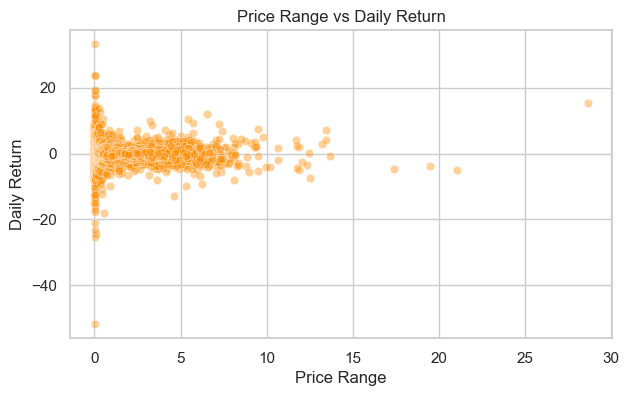

In [27]:
plt.figure(figsize=(7, 4))
sns.scatterplot(data=df.dropna(), x="Price_Range", y="Daily_Return", alpha=0.4, color="darkorange")
plt.title("Price Range vs Daily Return")
plt.xlabel("Price Range")
plt.ylabel("Daily Return")
plt.show()


Each point represents a trading day. PCA compresses the overall market behavior into fewer features, while the scatter plot gives an intuitive view of one original relationship.


## Completed Tasks


This notebook completes the required Assignment 2 tasks on the Apple stock dataset:

1. Loaded and inspected the dataset.
2. Corrected the `Date` data type.
3. Checked overall data quality, missing values, and duplicates.
4. Demonstrated three missing-value handling strategies.
5. Detected and handled outliers using `Volume`.
6. Applied Min-Max and Z-score normalization.
7. Examined correlations across numeric features.
8. Reduced dimensionality using PCA and visualized the result.
